<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/ADA_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ensemble Learning** -> Combination of Multiple MOdels.

**Bagging->**TRain many model independently and in parallel
Each models get a differant random sample of the data
final prediction is made usinh

.Majority Voting(Classification)

.Average(Regression)

**Boosting**->Insted of traning every observation equally,let's focus more on the mistakes

Webuild models sequencilly not in parallel

The Output of the model will become input for the next model



***ADA Boost (Adaptive Boosting) ->***

Imagin you are gussing answer in the class

Some student are okay,not brilliant

Many student are discussing together->Great Answer

Ada Boost-> turning many weak learners into one strong Learner

It trains the model one by one and each new model focuses more on the previous mistakes



**How ADA Bost Thinks->**
Ask qustion again and again
Which data points are we falling on> Let me focus more on that

So It will give more importance to the wrong answers
It will give less importance to the wrong answers

Importance=> Weight

**Step 1** Equal Importance(weight)
Every data points is going to get the same weight


**Step 2**
Train the first weak model
model makes some mistakes

**Step 3**
Increase the weight of the mistakes


**Step 4**
Trin next weak learner
This will focus on previous models' mistakes

**Step 5**
Reapet

**Step 6**

Final Decision
Strong Learner

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Dataset link -> https://drive.google.com/file/d/1sacUhRBfp8rO3Igm-I-6lpXYqYepnPBP/view

In [3]:
df = pd.read_csv("/content/census_income.csv")

In [4]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [6]:
df.duplicated().sum()

np.int64(24)

In [7]:
df.columns


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='object')

In [8]:
df.shape

(32561, 15)

In [9]:
df.replace([" ","?"],np.nan,inplace=True)

In [10]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [11]:
df.isnull().sum().sum()

np.int64(4262)

In [12]:
(4262/32561)*100

13.08927858481005

In [13]:
cols = ["workclass", "occupation", "native-country"]

for col in cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1005/4055168324.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
#Outliers
#Detact the outliers
#Handel the outliers


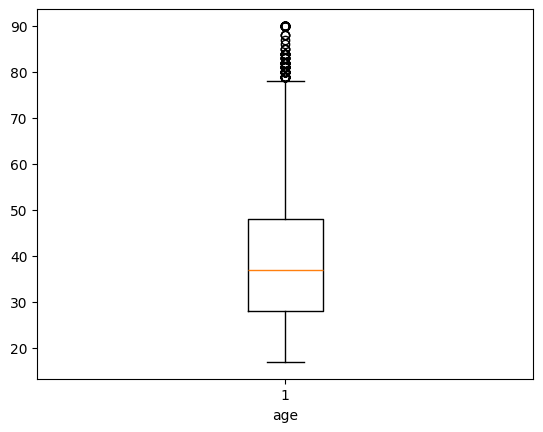

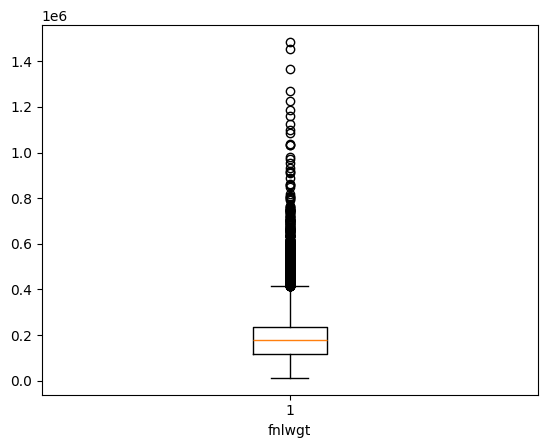

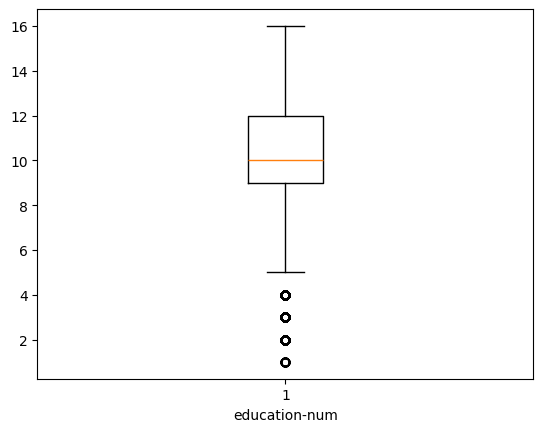

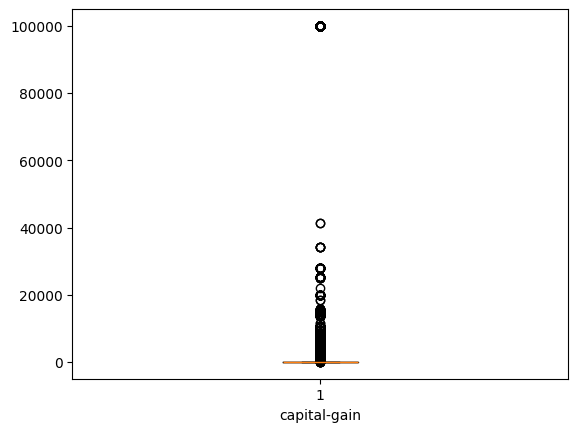

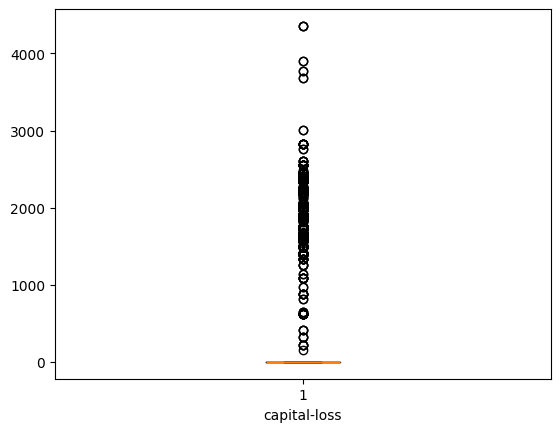

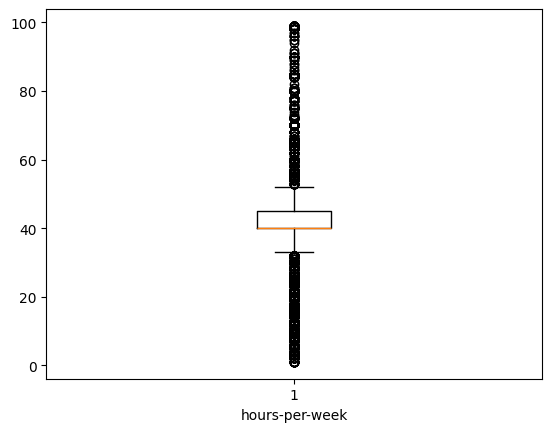

In [18]:
for i in df.columns:
  if df[i].dtype !="object":
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [19]:
cols = ["fnlwgt","hours-per-week"]

In [20]:
for col in cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  upper = Q3 + 1.5 * IQR
  lower = Q1 - 1.5 * IQR
  df = df[(df[col] >= lower) & (df[col] <= upper)]


In [21]:
df.shape

(22784, 15)

In [22]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

In [23]:
le =LabelEncoder()

In [24]:
for i in df.columns:
  if df[i].dtype == "object":
    df[i] = le.fit_transform(df[i])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22784 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             22784 non-null  int64
 1   workclass       22784 non-null  int64
 2   fnlwgt          22784 non-null  int64
 3   education       22784 non-null  int64
 4   education-num   22784 non-null  int64
 5   marital-status  22784 non-null  int64
 6   occupation      22784 non-null  int64
 7   relationship    22784 non-null  int64
 8   race            22784 non-null  int64
 9   sex             22784 non-null  int64
 10  capital-gain    22784 non-null  int64
 11  capital-loss    22784 non-null  int64
 12  hours-per-week  22784 non-null  int64
 13  native-country  22784 non-null  int64
 14  annual_income   22784 non-null  int64
dtypes: int64(15)
memory usage: 2.8 MB


In [26]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38,0
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4,0
5,37,3,284582,12,14,2,3,5,4,0,0,0,40,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,3,310152,15,10,4,10,1,4,1,0,0,40,38,0
32556,27,3,257302,7,12,2,12,5,4,0,0,0,38,38,0
32557,40,3,154374,11,9,2,6,0,4,1,0,0,40,38,1
32558,58,3,151910,11,9,6,0,4,4,0,0,0,40,38,0


In [27]:
#Logestic Regression model

In [28]:
x=df.drop("annual_income",axis=1)
y=df["annual_income"]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=24)

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
logestic_Model=LogisticRegression()

In [33]:
logestic_Model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [34]:
y_pred1=logestic_Model.predict(x_test)

In [35]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred1)

0.7882378757954794

In [36]:
#Decision Tree

from sklearn.tree import DecisionTreeClassifier

In [37]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [38]:
#Train model
y_pred2=model.predict(x_test)

In [39]:
#Test model
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred2)

0.804696071977178

In [40]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

In [41]:
random_model=RandomForestClassifier()
random_model.fit(x_train,y_train)

RandomForestClassifier()

In [42]:
#Traning
y_pred3=random_model.predict(x_test)

In [43]:
#Test model
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred3)

0.8516567917489577

In [44]:
#ADA Boost
from sklearn.ensemble import AdaBoostClassifier

In [45]:
Adboost_model = AdaBoostClassifier()
Adboost_model.fit(x_train,y_train)

AdaBoostClassifier()

In [46]:
#Traning
y_pred4=Adboost_model.predict(x_test)

In [47]:
#Testing Model
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred4)

0.848145709896862

**Gradint Boosting**

Focus on building multiple weak learners in sequence

Multiple weak learners add together and build a strong learner

It focus on the error of previous model and try to not repet the error of the previous model..

In [48]:
from sklearn.ensemble import GradientBoostingClassifier

In [49]:
model_Gradint = GradientBoostingClassifier()


In [50]:
model_Gradint.fit(x_train,y_train)

GradientBoostingClassifier()

In [51]:
y_predi5=model_Gradint.predict(x_test)

In [52]:
from sklearn.metrics import confusion_matrix

In [53]:
accuracy_score(y_test,y_predi5)

0.8613122668422207

In [54]:
confusion_matrix(y_test,y_predi5)

array([[3216,  188],
       [ 444,  709]])

In [55]:
from sklearn.metrics import classification_report

In [56]:
# Classification Report
classification_report(y_test,y_predi5)

'              precision    recall  f1-score   support\n\n           0       0.88      0.94      0.91      3404\n           1       0.79      0.61      0.69      1153\n\n    accuracy                           0.86      4557\n   macro avg       0.83      0.78      0.80      4557\nweighted avg       0.86      0.86      0.86      4557\n'

In [57]:
from xgboost import XGBClassifier

In [76]:
model_Xg = XGBClassifier(eta=0.12)

In [77]:
model_Xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eta=0.12, eval_metric=None,
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

In [78]:
y_pred = model_Xg.predict(x_test)

In [79]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [80]:
accuracy_score(y_test,y_pred)


0.8650427913100724

In [81]:
confusion_matrix(y_test,y_pred)

array([[3186,  218],
       [ 397,  756]])

In [82]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.89      0.94      0.91      3404\n           1       0.78      0.66      0.71      1153\n\n    accuracy                           0.87      4557\n   macro avg       0.83      0.80      0.81      4557\nweighted avg       0.86      0.87      0.86      4557\n'